## Bước 1: Kiểm tra GPU

In [ ]:
import os
os.environ.setdefault('TORCHDYNAMO_DISABLE', '1')  # Tránh lỗi vòng import torch._dynamo trên một số môi trường

import torch

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('TORCHDYNAMO_DISABLE =', os.environ.get('TORCHDYNAMO_DISABLE'))
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')
else:
    print('WARNING: Không có GPU! Hãy vào Runtime > Change runtime type > GPU')

PyTorch version: 2.10.0+cu128
CUDA available: True
TORCHDYNAMO_DISABLE = 1
GPU: Tesla T4
VRAM: 15.64 GB


## Bước 2: Cấu hình Google Drive (tùy chọn - để lưu model weights không bị mất)

In [ ]:
# Kết nối Google Drive (Required cho Colab)
from google.colab import drive
drive.mount('/content/drive')

import os

# === CẤU HÌNH ĐƯỜNG DẪN GOOGLE DRIVE CHO COLAB ===
# Trên Colab, Google Drive được mount tại /content/drive/MyDrive
DRIVE_SAVE_DIR = '/content/drive/MyDrive/U2Net_saved_models/u2net/saved_models'

if DRIVE_SAVE_DIR:
    os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
    print(f'Google Drive path OK: {DRIVE_SAVE_DIR}')
    print('Model sẽ được lưu vào Google Drive tự động.')
else:
    print('Google Drive chưa được cấu hình.')

Mounted at /content/drive
Google Drive path OK: /content/drive/MyDrive/U2Net_saved_models/u2net/saved_models
Model sẽ được lưu vào Google Drive tự động.


# Giải nén file U2Net

In [ ]:
import os

rar_file_path = '/content/drive/MyDrive/U2Net_saved_models/U-2-Net.rar'
extraction_path = '/content/'

# Cài đặt unrar nếu chưa có
if os.system('which unrar') != 0:
    print('Installing unrar...')
    os.system('apt-get update && apt-get install -y unrar-free')

# Giải nén file .rar
print(f'Extracting {rar_file_path} to {extraction_path}...')
os.makedirs(extraction_path, exist_ok=True)
exit_code = os.system(f'unrar x "{rar_file_path}" "{extraction_path}"')

if exit_code == 0:
    print('Extraction complete!')
    # Kiểm tra nội dung sau khi giải nén
    project_dir = os.path.join(extraction_path, 'U-2-Net')
    if os.path.exists(project_dir):
        print(f'Nội dung thư mục {project_dir}:')
        print(os.listdir(project_dir))
else:
    print('Error during extraction. Please check if the file exists at the specified path.')

Extracting /content/drive/MyDrive/U2Net_saved_models/U-2-Net.rar to /content/...
Extraction complete!
Nội dung thư mục /content/U-2-Net:
['train_data', 'data_loader.py', 'clipping_camera.jpg', 'u2net_test.py', 'saved_models', 'figures', 'test_data', 'model', '__pycache__', 'u2net_train.py', 'u2net_human_seg_test.py', 'setup_model_weights.py', 'README.md', 'requirements.txt', 'u2net_portrait_demo.py', 'LICENSE', 'u2net_portrait_test.py', 'u2net_portrait_composite.py', 'gradio']


## Bước 3: Kiểm tra cấu trúc thư mục project:

In [ ]:
import os

# Đường dẫn project trên Google Colab
PROJECT_DIR = '/content/U-2-Net'
os.chdir(PROJECT_DIR)
print(f'Project directory: {PROJECT_DIR}')
print(f'Nội dung thư mục:')
for item in os.listdir(PROJECT_DIR)[:20]:  # Chỉ hiển thị 20 item đầu tiên
    print(f'  {item}')

Project directory: /content/U-2-Net
Nội dung thư mục:
  train_data
  data_loader.py
  clipping_camera.jpg
  u2net_test.py
  saved_models
  figures
  test_data
  model
  __pycache__
  u2net_train.py
  u2net_human_seg_test.py
  setup_model_weights.py
  README.md
  requirements.txt
  u2net_portrait_demo.py
  LICENSE
  u2net_portrait_test.py
  u2net_portrait_composite.py
  gradio


## Bước 4: Cài đặt thư viện

In [ ]:
# import subprocess, sys
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-image', 'pillow', 'numpy', 'scikit-learn', '-q'])
# print('Cài đặt hoàn tất!')

## Bước 5: Chuẩn bị Dataset

**Upload Dataset.rar lên drive rồi giải nén**
Nếu đã giải nén rồi thì khi chạy lại có thể bỏ qua cell này.

Dataset DUTS-TR (~1.3GB) gồm ~10,000 ảnh training. Tải về từ: http://saliencydetection.net/duts/

In [ ]:
import os
import glob

# CONFIG
DATASET_NAME = 'DUTS-TR'
DUTS_RAR_PATH = '/content/drive/MyDrive/U2Net_saved_models/train_data/DUTS-TR.rar'
TRAIN_DATA_DIR = '/content/U-2-Net/train_data/DUTS'

os.makedirs(TRAIN_DATA_DIR, exist_ok=True)

# CHECK FILE
if not os.path.exists(DUTS_RAR_PATH):
    raise FileNotFoundError(f'Không tìm thấy file rar: {DUTS_RAR_PATH}')

# INSTALL UNRAR
if os.system('which unrar >/dev/null 2>&1') != 0:
    print('Installing unrar...')
    os.system('apt-get update -qq && apt-get install -y unrar')

# EXTRACT
print(f'Giải nén {DUTS_RAR_PATH} -> {TRAIN_DATA_DIR}')
extract_code = os.system(f'unrar x -o+ "{DUTS_RAR_PATH}" "{TRAIN_DATA_DIR}"')

if extract_code != 0:
    raise RuntimeError('Giải nén thất bại')

# AUTO DETECT FOLDER
image_dir = None
mask_dir = None

for root, dirs, files in os.walk(TRAIN_DATA_DIR):
    for d in dirs:
        d_lower = d.lower()

        if 'image' in d_lower:
            image_dir = os.path.join(root, d)

        if 'mask' in d_lower or 'gt' in d_lower:
            mask_dir = os.path.join(root, d)

# VALIDATE
if image_dir is None or mask_dir is None:
    raise RuntimeError(
        f'''
Không tìm thấy folder Image/Mask.

Structure hiện tại:
{list(os.walk(TRAIN_DATA_DIR))[:3]}
'''
    )

# CONFIG
DATASET_CONFIG = {
    'DUTS-TR': {
        'data_dir': TRAIN_DATA_DIR,
        'train_image_dir': image_dir,
        'train_label_dir': mask_dir,
        'check_image_dir': image_dir,
        'check_mask_dir': mask_dir,
    }
}

dataset_cfg = DATASET_CONFIG[DATASET_NAME]

# PRINT INFO
print('\n===== DATASET INFO')
print(f'Image dir: {dataset_cfg["check_image_dir"]}')
print(f'Mask dir: {dataset_cfg["check_mask_dir"]}')

# COUNT FILE
image_patterns = ['*.jpg', '*.jpeg', '*.png', '*.bmp']

num_imgs = sum(
    len(glob.glob(os.path.join(image_dir, p)))
    for p in image_patterns
)

num_masks = len(glob.glob(os.path.join(mask_dir, '*.png')))

print(f'\nSố ảnh: {num_imgs}')
print(f'Số mask: {num_masks}')

# CHECK MISMATCH
if num_imgs != num_masks:
    print('\n WARNING: Số ảnh và mask không bằng nhau!')
else:
    print('\n Dataset OK (ảnh = mask)')

### Cấu hình Validation Dataset

In [ ]:
import os
import glob
import shutil

# CHỌN PHƯƠNG PHÁP VALIDATION
USE_SEPARATE_VAL = True  # True: dùng dataset riêng | False: tách 80/20 từ training

TEST_DATA_DIR = os.path.join(PROJECT_DIR, 'test_data')
os.makedirs(TEST_DATA_DIR, exist_ok=True)

if USE_SEPARATE_VAL:
    print('VALIDATION: SEPARATE DATASET')
    print(f'Destination: {TEST_DATA_DIR}')
    print()

    VAL_RAR_PATH = '/content/drive/MyDrive/U2Net_saved_models/train_data/ECSSD.rar'

    if os.path.exists(VAL_RAR_PATH):
        print(f'File tìm thấy: {VAL_RAR_PATH}')
        print(f'Kích thước: {os.path.getsize(VAL_RAR_PATH) / 1e9:.2f} GB')
        print()
        print('Giải nén...')

        # Cài đặt unrar
        if os.name == 'nt':
            if os.system('where unrar >nul 2>&1') != 0:
                print('Cảnh báo: unrar chưa cài. Hãy cài từ https://www.rarlab.com/')
        else:
            if os.system('which unrar >/dev/null 2>&1') != 0:
                print('Installing unrar...')
                os.system('apt-get update -qq && apt-get install -y unrar')

        # Giải nén
        extract_cmd = f'unrar x -o+ "{VAL_RAR_PATH}" "{TEST_DATA_DIR}"'
        extract_code = os.system(extract_cmd)

        if extract_code == 0:
            print(f'✓ Giải nén thành công')
        else:
            raise RuntimeError(f'Giải nén thất bại (exit code {extract_code})')
    else:
        print(f'Chưa tìm thấy: {VAL_RAR_PATH}')
        print('Bạn có thể:')
        print('  1. Upload file .rar lên Google Drive (nếu Colab), rồi đặt đường dẫn /content/drive/MyDrive/...rar')
        print('  2. Đặt đường dẫn local: C:/Users/Admin/Downloads/DUTS-TE.rar')
        print('  3. Để trống để tự động tách 80/20 từ training set')
        raise FileNotFoundError(f'Không tìm thấy validation dataset: {VAL_RAR_PATH}')

    # AUTO DETECT FOLDER
    print()
    print('Tìm kiếm thư mục images/masks trong giải nén...')

    val_image_dir = None
    val_label_dir = None

    for root, dirs, files in os.walk(TEST_DATA_DIR):
        for d in dirs:
            d_lower = d.lower()
            if 'image' in d_lower or 'img' in d_lower:
                val_image_dir = os.path.join(root, d)
            if 'mask' in d_lower or 'gt' in d_lower or 'label' in d_lower:
                val_label_dir = os.path.join(root, d)

    if val_image_dir is None or val_label_dir is None:
        print('Cảnh báo: Không tìm thấy thư mục image/mask tự động')
        print('Cấu trúc hiện tại:')
        for root, dirs, files in list(os.walk(TEST_DATA_DIR))[:5]:
            level = root.replace(TEST_DATA_DIR, '').count(os.sep)
            indent = ' ' * 2 * level
            print(f'{indent}{os.path.basename(root)}/')
            sub_indent = ' ' * 2 * (level + 1)
            for d in dirs[:5]:
                print(f'{sub_indent}{d}/')

        raise RuntimeError('Hãy chỉnh lại cấu trúc thư mục validation')

    print(f'✓ Image dir found: {val_image_dir}')
    print(f'✓ Label dir found: {val_label_dir}')

    # Count files
    num_val_imgs = sum(
        len(glob.glob(os.path.join(val_image_dir, f'*.{ext}')))
        for ext in ('jpg', 'jpeg', 'png', 'bmp')
    )
    num_val_masks = len(glob.glob(os.path.join(val_label_dir, '*.png')))

    print(f'Validation images: {num_val_imgs}')
    print(f'Validation masks:  {num_val_masks}')
else:
    print('VALIDATION: SPLIT 80/20 từ TRAINING')
    print('sẽ tách 80% train / 20% validation từ dataset training')

In [ ]:
# Kiểm tra cấu trúc dataset
import glob
import os

if 'DATASET_NAME' not in globals() or 'DATASET_CONFIG' not in globals():
    raise RuntimeError('Hãy chạy cell chọn dataset trước (cell ngay trên).')

dataset_cfg = DATASET_CONFIG[DATASET_NAME]
image_dir = dataset_cfg['check_image_dir']
mask_dir = dataset_cfg['check_mask_dir']

image_patterns = [
    os.path.join(image_dir, '*.jpg'),
    os.path.join(image_dir, '*.jpeg'),
    os.path.join(image_dir, '*.png'),
    os.path.join(image_dir, '*.bmp'),
]
train_imgs = []
for pattern in image_patterns:
    train_imgs.extend(glob.glob(pattern))

train_lbls = glob.glob(os.path.join(mask_dir, '*.png'))

print(f'Dataset: {DATASET_NAME}')
print(f'Số ảnh training tìm thấy: {len(train_imgs)}')
print(f'Số nhãn training tìm thấy: {len(train_lbls)}')

if len(train_imgs) == 0:
    print('\nWARNING: Không tìm thấy ảnh! Kiểm tra lại cấu trúc thư mục:')
    print(f'  {image_dir}')
if len(train_lbls) == 0:
    print('\nWARNING: Không tìm thấy mask! Kiểm tra lại cấu trúc thư mục:')
    print(f'  {mask_dir}')
if len(train_imgs) > 0 and len(train_lbls) > 0:
    print('\nDataset OK!')

Số ảnh training tìm thấy: 10553
Số nhãn training tìm thấy: 10553

Dataset OK!


## Bước 6: Cấu hình và bắt đầu Training

In [ ]:
import os
import torch
import torchvision
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
import numpy as np
import glob
import sys
import shutil

# Thêm đường dẫn project
sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)

from data_loader import RescaleT, RandomCrop, RandomHFlip, RandomBrightContrast, RandomRotation, ToTensorLab, SalObjDataset
from model import U2NET, U2NETP

print('Import thành công!')

# Đường dẫn checkpoint trên Google Drive (Colab)
CHECKPOINT_DIR = '/content/drive/MyDrive/U2Net_saved_models/u2net/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f'Checkpoint dir: {CHECKPOINT_DIR}')

Import thành công!
Checkpoint dir: /content/drive/MyDrive/U2Net_saved_models/u2net/checkpoints


In [ ]:
MODEL_NAME   = 'u2net'   # 'u2net' (nặng, chính xác hơn) hoặc 'u2netp' (nhẹ, nhanh hơn)
EPOCH_NUM    = 35        # Số epoch
BATCH_SIZE   = 2        # Đã giảm xuống 1 để tránh lỗi CUDA Out of Memory
LR           = 0.0001     # Learning rate (giữ nguyên như original training)
WEIGHT_DECAY = 1e-4      # L2 regularization để chống overfitting
SAVE_FRQ     = 20000       # Lưu model mỗi N iterations
RESUME_CKPT  = os.path.join(CHECKPOINT_DIR, 'u2net_epoch_30.pth')
SAVE_EPOCH_FRQ = 5        # Lưu model mỗi N epochs

# === ANTI-OVERFITTING CONFIG ===
PATIENCE     = 7         # Early stopping: dừng nếu val loss không giảm sau N epochs

#========================================================
# === CHỌN SCHEDULER: 'cosine' hoặc 'plateau'===========
#========================================================
# 'cosine'  -> CosineAnnealingLR: giảm LR theo hàm cosine, phù hợp fine-tuning ổn định
# 'plateau' -> ReduceLROnPlateau: giảm LR khi val loss không giảm, phản ứng nhanh khi overfitting
SCHEDULER_TYPE = 'plateau'   # <<< ĐỔI GIÁ TRỊ NÀY ĐỂ THỬ SCHEDULER KHÁC

# --- Tham số CosineAnnealingLR (chỉ dùng khi SCHEDULER_TYPE = 'cosine') ---
COSINE_T_MAX = 10        # Chu kỳ cosine (số epochs cho 1 nửa chu kỳ)
COSINE_ETA_MIN = 1e-6    # LR tối thiểu của cosine

# --- Tham số ReduceLROnPlateau (chỉ dùng khi SCHEDULER_TYPE = 'plateau') ---
SCHEDULER_PATIENCE = 3   # Giảm LR nếu val loss không giảm sau N epochs
SCHEDULER_FACTOR = 0.5   # Hệ số giảm LR (LR mới = LR cũ * factor)
SCHEDULER_MIN_LR = 1e-6  # LR tối thiểu

# Dataset config lấy từ cell chọn dataset global
if 'DATASET_NAME' not in globals() or 'DATASET_CONFIG' not in globals():
    raise RuntimeError('Hãy chạy cell chọn dataset trước (ở Bước 5).')

dataset_cfg = DATASET_CONFIG[DATASET_NAME]
DATA_DIR = dataset_cfg['data_dir']
TRA_IMAGE_DIR = dataset_cfg['train_image_dir']
TRA_LABEL_DIR = dataset_cfg['train_label_dir']

# Thư mục lưu model trên Google Drive (Colab)
MODEL_DIR = '/content/drive/MyDrive/U2Net_saved_models/u2net/saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'Model:      {MODEL_NAME}')
print(f'Epochs:     {EPOCH_NUM}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Weight decay: {WEIGHT_DECAY}')
print(f'Early stopping patience: {PATIENCE} epochs')
print(f'Dataset:    {DATASET_NAME}')
print(f'Data dir:   {DATA_DIR}')
print(f'>>> Scheduler đang dùng: {SCHEDULER_TYPE.upper()}')
if SCHEDULER_TYPE == 'cosine':
    print(f'    CosineAnnealingLR: T_max={COSINE_T_MAX}, eta_min={COSINE_ETA_MIN}')
else:
    print(f'    ReduceLROnPlateau: patience={SCHEDULER_PATIENCE}, factor={SCHEDULER_FACTOR}, min_lr={SCHEDULER_MIN_LR}')
print(f'Save dir (Drive): {MODEL_DIR}')
print(f'Checkpoint dir (Drive): {CHECKPOINT_DIR}')
print(f'Lưu checkpoint mỗi {SAVE_EPOCH_FRQ} epochs')
print(f'Resume:     {RESUME_CKPT}')
if RESUME_CKPT:
    print(f'File tồn tại: {os.path.exists(RESUME_CKPT)}')

Model:      u2net
Epochs:     35
Batch size: 2
Weight decay: 0.0001
Early stopping patience: 7 epochs
>>> Scheduler đang dùng: PLATEAU
    ReduceLROnPlateau: patience=3, factor=0.5, min_lr=1e-06
Save dir (Drive): /content/drive/MyDrive/U2Net_saved_models/u2net/saved_models
Checkpoint dir (Drive): /content/drive/MyDrive/U2Net_saved_models/u2net/checkpoints
Lưu checkpoint mỗi 5 epochs
Resume:     /content/drive/MyDrive/U2Net_saved_models/u2net/checkpoints/u2net_epoch_30.pth
File tồn tại: True


### Tách dữ liệu thành Training và Validation Sets (Tùy chọn)

Nếu bạn muốn theo dõi hiệu suất của mô hình trên một tập dữ liệu validation riêng biệt để đánh giá overfitting, bạn có thể thực hiện việc tách dữ liệu như sau. Điều này sẽ giúp bạn hiểu rõ hơn về khả năng tổng quát hóa của mô hình.

In [ ]:
import glob
import os
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torchvision import transforms

# Hàm collate tùy chỉnh để sửa lỗi ép kiểu (Byte to Float)
def custom_collate(batch):
    images = []
    labels = []
    imidxs = []
    for item in batch:
        images.append(item['image'].float())
        labels.append(item['label'].float())
        imidxs.append(item['imidx'])
    return {
        'image': torch.stack(images, 0),
        'label': torch.stack(labels, 0),
        'imidx': torch.stack(imidxs, 0)
    }

# Lấy danh sách ảnh và nhãn từ thư mục
image_patterns = [
    os.path.join(DATA_DIR, TRA_IMAGE_DIR, '*.jpg'),
    os.path.join(DATA_DIR, TRA_IMAGE_DIR, '*.jpeg'),
    os.path.join(DATA_DIR, TRA_IMAGE_DIR, '*.png'),
    os.path.join(DATA_DIR, TRA_IMAGE_DIR, '*.bmp'),
]
tra_img_name_list = []
for pattern in image_patterns:
    tra_img_name_list.extend(glob.glob(pattern))

tra_lbl_name_list = []
for img_path in tra_img_name_list:
    img_name = os.path.basename(img_path)
    imidx = os.path.splitext(img_name)[0]
    tra_lbl_name_list.append(os.path.join(DATA_DIR, TRA_LABEL_DIR, imidx + '.png'))

# Chia thành tập train (80%) và tập validation (20%)
paired_data = list(zip(tra_img_name_list, tra_lbl_name_list))
train_pairs, val_pairs = train_test_split(paired_data, test_size=0.2, random_state=42)

train_img_list, train_lbl_list = zip(*train_pairs)
val_img_list, val_lbl_list = zip(*val_pairs)

# DataLoader cho tập train với custom_collate
salobj_dataset_train = SalObjDataset(
    img_name_list=list(train_img_list),
    lbl_name_list=list(train_lbl_list),
    transform=transforms.Compose([
        RescaleT(320),
        RandomCrop(256),
        ToTensorLab(flag=0)
    ])
)
salobj_dataloader_train = DataLoader(
    salobj_dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=custom_collate
)

# DataLoader cho tập validation với custom_collate
salobj_dataset_val = SalObjDataset(
    img_name_list=list(val_img_list),
    lbl_name_list=list(val_lbl_list),
    transform=transforms.Compose([
        RescaleT(320),
        ToTensorLab(flag=0)
    ])
)
salobj_dataloader_val = DataLoader(
    salobj_dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=custom_collate
)

print('DataLoader đã được cập nhật với custom_collate để sửa lỗi TypeError!')

DataLoader đã được cập nhật với custom_collate để sửa lỗi TypeError!


In [ ]:
# ------- 0. Giải phóng GPU memory --------
import gc
try:
    del net
except:
    pass
try:
    del optimizer
except:
    pass
try:
    del scheduler
except:
    pass
gc.collect()
try:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f'GPU memory đã giải phóng. Free: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB / {torch.cuda.mem_get_info()[1]/1e9:.2f} GB')
except RuntimeError:
    print('WARNING: Không thể giải phóng GPU memory. Hãy Restart Kernel rồi chạy lại từ Cell 1.')
    raise SystemExit('Restart Kernel required!')

# ------- 1. define loss function --------
bce_loss = nn.BCELoss(size_average=True)

def muti_bce_loss_fusion(d0, d1, d2, d3, d4, d5, d6, labels_v):
    loss0 = bce_loss(d0, labels_v)
    loss1 = bce_loss(d1, labels_v)
    loss2 = bce_loss(d2, labels_v)
    loss3 = bce_loss(d3, labels_v)
    loss4 = bce_loss(d4, labels_v)
    loss5 = bce_loss(d5, labels_v)
    loss6 = bce_loss(d6, labels_v)
    loss = loss0 + loss1 + loss2 + loss3 + loss4 + loss5 + loss6
    print("l0: %3f, l1: %3f, l2: %3f, l3: %3f, l4: %3f, l5: %3f, l6: %3f" % (
        loss0.data.item(), loss1.data.item(), loss2.data.item(), loss3.data.item(),
        loss4.data.item(), loss5.data.item(), loss6.data.item()))
    return loss0, loss

# ------- 2. define model --------
if MODEL_NAME == 'u2net':
    net = U2NET(3, 1)
elif MODEL_NAME == 'u2netp':
    net = U2NETP(3, 1)

if torch.cuda.is_available():
    net.cuda()
    print(f'Model đang chạy trên: {torch.cuda.get_device_name(0)}')
    print(f'GPU memory sau khi load model: {torch.cuda.memory_allocated()/1e9:.2f} GB used')
else:
    print('WARNING: Đang chạy trên CPU! Training sẽ rất chậm.')

# ------- 3. define optimizer + scheduler --------
print("---define optimizer...")

def _build_adam_with_dynamo_fallback(model):
    """Tạo Adam optimizer và fallback nếu lỗi torch._dynamo circular import."""
    try:
        return optim.Adam(
            model.parameters(),
            lr=LR,
            betas=(0.9, 0.999),
            eps=1e-08,
            weight_decay=WEIGHT_DECAY,
        )
    except AttributeError as e:
        if 'torch._dynamo' not in str(e):
            raise

        print('WARNING: Lỗi torch._dynamo khi tạo optimizer. Áp dụng fallback disable dynamo...')

        if hasattr(torch.optim.Optimizer.add_param_group, '__wrapped__'):
            torch.optim.Optimizer.add_param_group = torch.optim.Optimizer.add_param_group.__wrapped__
            print('  Đã bypass wrapper torch._dynamo trong Optimizer.add_param_group.')

        try:
            return optim.Adam(
                model.parameters(),
                lr=LR,
                betas=(0.9, 0.999),
                eps=1e-08,
                weight_decay=WEIGHT_DECAY,
            )
        except Exception as e2:
            raise RuntimeError(
                'Không thể tạo optimizer do môi trường PyTorch bị lỗi. '
                'Khuyến nghị: restart kernel, sau đó cài lại torch + torchvision tương thích.'
            ) from e2

optimizer = _build_adam_with_dynamo_fallback(net)
print(f'  Weight decay (L2 reg): {WEIGHT_DECAY}')

# Tạo scheduler dựa trên SCHEDULER_TYPE
if SCHEDULER_TYPE == 'cosine':
    scheduler = CosineAnnealingLR(optimizer, T_max=COSINE_T_MAX, eta_min=COSINE_ETA_MIN)
    print(f'  Scheduler: CosineAnnealingLR (T_max={COSINE_T_MAX}, eta_min={COSINE_ETA_MIN})')
elif SCHEDULER_TYPE == 'plateau':
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=SCHEDULER_FACTOR,
                                   patience=SCHEDULER_PATIENCE, min_lr=SCHEDULER_MIN_LR)
    print(f'  Scheduler: ReduceLROnPlateau (patience={SCHEDULER_PATIENCE}, factor={SCHEDULER_FACTOR}, min_lr={SCHEDULER_MIN_LR})')
else:
    raise ValueError(f"SCHEDULER_TYPE không hợp lệ: '{SCHEDULER_TYPE}'. Chọn 'cosine' hoặc 'plateau'.")

# ------- 4. load checkpoint nếu có --------
start_epoch = 0
ite_num = 0
checkpoint = None
train_losses_per_epoch = []
val_losses_per_epoch = []
best_val_loss = float('inf')
early_stop_counter = 0

# === METRIC HISTORY ===
mae_per_epoch = []
maxF_per_epoch = []
sm_per_epoch = []
lr_per_epoch = []

LOAD_OPTIMIZER_STATE = True

if RESUME_CKPT:
    if os.path.exists(RESUME_CKPT):
        checkpoint = torch.load(RESUME_CKPT, map_location='cpu')
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            net.load_state_dict(checkpoint['model_state_dict'])
            start_epoch = checkpoint.get('epoch', 0)
            ite_num = checkpoint.get('ite_num', 0)
            train_losses_per_epoch = checkpoint.get('train_losses_per_epoch', [])
            val_losses_per_epoch = checkpoint.get('val_losses_per_epoch', [])
            mae_per_epoch = checkpoint.get('mae_per_epoch', [])
            maxF_per_epoch = checkpoint.get('maxF_per_epoch', [])
            sm_per_epoch = checkpoint.get('sm_per_epoch', [])
            lr_per_epoch = checkpoint.get('lr_per_epoch', [])

            if val_losses_per_epoch:
                best_val_loss = min(val_losses_per_epoch)
                print(f'  Best val loss từ checkpoint: {best_val_loss:.4f}')

            if LOAD_OPTIMIZER_STATE and 'optimizer_state_dict' in checkpoint:
                optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
                print(f'Đã load optimizer state (giữ momentum). LR từ checkpoint: {optimizer.param_groups[0]["lr"]}')
            else:
                print(f'Dùng optimizer MỚI với LR = {LR} (không load state cũ)')

            if SCHEDULER_TYPE == 'cosine':
                for _ in range(start_epoch):
                    scheduler.step()

            print(f'Đã load checkpoint: {RESUME_CKPT} (Epoch {start_epoch}, Iter {ite_num})')
        else:
            net.load_state_dict(checkpoint)
            print(f'Đã load trọng số model từ: {RESUME_CKPT}')
    else:
        print(f'LỖI: Không tìm thấy file tại {RESUME_CKPT}')
else:
    print('Bắt đầu training từ đầu (không có checkpoint).')

print(f'Optimizer LR: {optimizer.param_groups[0]["lr"]}')
print(f'Early stopping patience: {PATIENCE} epochs')
print(f'Scheduler: {SCHEDULER_TYPE.upper()}')
print('Model và Optimizer sẵn sàng!')

GPU memory đã giải phóng. Free: 15.53 GB / 15.64 GB
Model đang chạy trên: Tesla T4
GPU memory sau khi load model: 0.18 GB used
---define optimizer...
  Weight decay (L2 reg): 0.0001
  Scheduler: ReduceLROnPlateau (patience=3, factor=0.5, min_lr=1e-06)
  Best val loss từ checkpoint: 0.9868
Đã load optimizer state (giữ momentum). LR từ checkpoint: 0.0001
Đã load checkpoint: /content/drive/MyDrive/U2Net_saved_models/u2net/checkpoints/u2net_epoch_30.pth (Epoch 30, Iter 120815)
Optimizer LR: 0.0001
Early stopping patience: 7 epochs
Scheduler: PLATEAU
Model và Optimizer sẵn sàng!


In [ ]:
# ------- 5. training process --------
import numpy as np
import matplotlib.pyplot as plt

print("---start training...")
print(f"Fine-tuning với Scheduler: {SCHEDULER_TYPE.upper()}")
print(f"Train: 80% | Validation: 20%")
print(f"Anti-overfitting: weight_decay={WEIGHT_DECAY}, LR scheduler ({SCHEDULER_TYPE}), early stopping (patience={PATIENCE}), data augmentation")

train_num = len(train_img_list)
val_num = len(val_img_list)

ite_num = ite_num  # giữ từ checkpoint nếu có
running_loss = 0.0
running_tar_loss = 0.0
ite_num4val = 0
save_frq = SAVE_FRQ  # save the model every N iterations

# Đường dẫn lưu figures trên Google Drive (Colab)
fig_dir = '/content/drive/MyDrive/U2Net_saved_models/u2net/saved_models'
os.makedirs(fig_dir, exist_ok=True)

def save_checkpoint_to_drive(filename):
    """Copy checkpoint lên Google Drive nếu đã cấu hình"""
    if CHECKPOINT_DIR:
        try:
            drive_path = os.path.join(CHECKPOINT_DIR, filename)
            shutil.copy2(os.path.join(MODEL_DIR, filename), drive_path)
            print(f'  >>> Đã copy lên Google Drive checkpoints: {drive_path}')
        except Exception as e:
            print(f'  >>> LỖI khi copy lên Drive: {e}')

def _save_training_figures():
    if len(train_losses_per_epoch) == 0:
        return

    x_epochs = list(range(1, len(train_losses_per_epoch) + 1))

    # Figure 1: Loss
    fig1, ax1 = plt.subplots(figsize=(7, 4))
    ax1.plot(x_epochs, train_losses_per_epoch, label='Train Loss', linewidth=2)
    ax1.plot(x_epochs, val_losses_per_epoch, label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.35)
    if len(val_losses_per_epoch) > 0:
        best_epoch_idx = int(np.argmin(val_losses_per_epoch)) + 1
        ax1.axvline(x=best_epoch_idx, linestyle='--', color='red', label=f'Best Epoch ({best_epoch_idx})')
        ax1.scatter(best_epoch_idx, val_losses_per_epoch[best_epoch_idx - 1], color='red', zorder=5)
    ax1.legend(loc='upper right')
    ax1.set_title('Loss Curve')
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, 'u2net_loss_curve.png'), dpi=220)
    plt.close(fig1)

    # Figure 2: Metrics
    fig2, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(x_epochs, maxF_per_epoch, label='maxFβ', marker='o', markersize=4)
    axes[0].plot(x_epochs, sm_per_epoch, label='S-measure (proxy)', marker='s', markersize=4)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Score (higher is better)')
    axes[0].set_ylim(0, 1)
    axes[0].grid(True, alpha=0.35)
    axes[0].legend(loc='lower right', fontsize=9)
    axes[0].set_title('Segmentation Metrics (higher ↑)')

    axes[1].plot(x_epochs, mae_per_epoch, label='MAE', color='tomato', marker='o', markersize=4)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE (lower is better)')
    axes[1].grid(True, alpha=0.35)
    axes[1].legend(loc='upper right', fontsize=9)
    axes[1].set_title('Mean Absolute Error (lower ↓)')

    plt.suptitle('U2Net Evaluation Metrics (Training-time)', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, 'u2net_metrics_curve.png'), dpi=220, bbox_inches='tight')
    plt.close(fig2)

    # Figure 3: Learning rate
    fig3, ax3 = plt.subplots(figsize=(7, 4))
    if len(lr_per_epoch) > 0:
        ax3.plot(x_epochs, lr_per_epoch, linewidth=2, label='Learning Rate')
        ax3.set_yscale('log')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('LR')
    ax3.grid(True, alpha=0.35)
    ax3.legend(loc='upper right')
    ax3.set_title('Learning Rate Schedule')
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, 'u2net_lr_schedule.png'), dpi=220)
    plt.close(fig3)

for epoch in range(start_epoch, EPOCH_NUM):
    net.train()

    epoch_train_loss = 0.0
    epoch_train_tar_loss = 0.0
    epoch_batch_count = 0

    for i, data in enumerate(salobj_dataloader_train):
        ite_num = ite_num + 1
        ite_num4val = ite_num4val + 1

        inputs, labels = data['image'], data['label']
        inputs = inputs.type(torch.FloatTensor)
        labels = labels.type(torch.FloatTensor)

        if torch.cuda.is_available():
            inputs_v, labels_v = Variable(inputs.cuda(), requires_grad=False), Variable(labels.cuda(), requires_grad=False)
        else:
            inputs_v, labels_v = Variable(inputs, requires_grad=False), Variable(labels, requires_grad=False)

        optimizer.zero_grad()

        d0, d1, d2, d3, d4, d5, d6 = net(inputs_v)
        loss2, loss = muti_bce_loss_fusion(d0, d1, d2, d3, d4, d5, d6, labels_v)

        loss.backward()
        optimizer.step()

        running_loss += loss.data.item()
        running_tar_loss += loss2.data.item()

        epoch_train_loss += loss.data.item()
        epoch_train_tar_loss += loss2.data.item()
        epoch_batch_count += 1

        del d0, d1, d2, d3, d4, d5, d6, loss2, loss

        print("[epoch: %3d/%3d, batch: %5d/%5d, ite: %d] train loss: %3f, tar: %3f " % (
            epoch + 1, EPOCH_NUM, (i + 1) * BATCH_SIZE, train_num, ite_num,
            running_loss / ite_num4val, running_tar_loss / ite_num4val))

        if ite_num % save_frq == 0:
            # Không lưu checkpoint trung gian vào saved_models
            running_loss = 0.0
            running_tar_loss = 0.0
            net.train()
            ite_num4val = 0

    avg_train_loss = epoch_train_loss / epoch_batch_count if epoch_batch_count > 0 else 0.0
    avg_train_tar = epoch_train_tar_loss / epoch_batch_count if epoch_batch_count > 0 else 0.0
    train_losses_per_epoch.append(avg_train_loss)

    # --- Validation sau mỗi epoch ---
    net.eval()
    val_loss_sum = 0.0
    val_tar_sum = 0.0
    val_batch_count = 0

    # Training-time metrics (nhanh)
    mae_sum = 0.0
    f_sum = 0.0

    with torch.no_grad():
        for i_val, data_val in enumerate(salobj_dataloader_val):
            inputs_val, labels_val = data_val['image'], data_val['label']
            inputs_val = inputs_val.type(torch.FloatTensor)
            labels_val = labels_val.type(torch.FloatTensor)

            if torch.cuda.is_available():
                inputs_v_val = Variable(inputs_val.cuda(), requires_grad=False)
                labels_v_val = Variable(labels_val.cuda(), requires_grad=False)
            else:
                inputs_v_val = Variable(inputs_val, requires_grad=False)
                labels_v_val = Variable(labels_val, requires_grad=False)

            d0_v, d1_v, d2_v, d3_v, d4_v, d5_v, d6_v = net(inputs_v_val)
            loss2_v = bce_loss(d0_v, labels_v_val)
            loss_v = bce_loss(d0_v, labels_v_val) + bce_loss(d1_v, labels_v_val) + bce_loss(d2_v, labels_v_val) + \
                     bce_loss(d3_v, labels_v_val) + bce_loss(d4_v, labels_v_val) + bce_loss(d5_v, labels_v_val) + \
                     bce_loss(d6_v, labels_v_val)

            val_loss_sum += loss_v.data.item()
            val_tar_sum += loss2_v.data.item()
            val_batch_count += 1

            # MAE thực
            mae_sum += torch.mean(torch.abs(d0_v - labels_v_val)).item()

            # maxF proxy tại threshold 0.5 (nhanh hơn full 255 thresholds)
            pred_bin = (d0_v >= 0.5).float()
            gt_bin = (labels_v_val >= 0.5).float()
            tp = (pred_bin * gt_bin).sum().item()
            prec = tp / (pred_bin.sum().item() + 1e-8)
            rec = tp / (gt_bin.sum().item() + 1e-8)
            f_val = (1 + 0.3) * prec * rec / (0.3 * prec + rec + 1e-8)
            f_sum += f_val

            del d0_v, d1_v, d2_v, d3_v, d4_v, d5_v, d6_v

    avg_val_loss = val_loss_sum / val_batch_count if val_batch_count > 0 else 0.0
    avg_val_tar = val_tar_sum / val_batch_count if val_batch_count > 0 else 0.0
    val_losses_per_epoch.append(avg_val_loss)

    epoch_mae = mae_sum / val_batch_count if val_batch_count > 0 else 0.0
    epoch_maxf = f_sum / val_batch_count if val_batch_count > 0 else 0.0
    epoch_sm_proxy = max(0.0, min(1.0, 1.0 - epoch_mae))

    mae_per_epoch.append(epoch_mae)
    maxF_per_epoch.append(epoch_maxf)
    sm_per_epoch.append(epoch_sm_proxy)

    # === SCHEDULER STEP ===
    lr_before = optimizer.param_groups[0]['lr']
    if SCHEDULER_TYPE == 'cosine':
        scheduler.step()
    elif SCHEDULER_TYPE == 'plateau':
        scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    lr_per_epoch.append(current_lr)

    print(f'  [Scheduler {SCHEDULER_TYPE.upper()}] LR: {lr_before:.2e} -> {current_lr:.2e}')
    print("\n" + "=" * 70)
    print("[Epoch %3d/%3d Summary] Train Loss: %.4f, Train Tar: %.4f | Val Loss: %.4f, Val Tar: %.4f | LR: %.2e" % (
        epoch + 1, EPOCH_NUM, avg_train_loss, avg_train_tar, avg_val_loss, avg_val_tar, current_lr))
    print(f"  [Metrics] MAE={epoch_mae:.4f} | maxF(proxy)={epoch_maxf:.4f} | Sm(proxy)={epoch_sm_proxy:.4f}")

    # === EARLY STOPPING (khong luu best model vao saved_models) ===
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        print(f'  >>> Val Loss cải thiện tốt nhất: {avg_val_loss:.4f} (Epoch {epoch+1})')
    else:
        early_stop_counter += 1
        print(f'  >>> Val Loss không cải thiện ({early_stop_counter}/{PATIENCE})')

    _save_training_figures()

    print("=" * 70 + "\n")

    if early_stop_counter >= PATIENCE:
        print(f'*** EARLY STOPPING tại Epoch {epoch+1}! Val Loss không giảm sau {PATIENCE} epochs liên tiếp. ***')
        print(f'*** Best Val Loss: {best_val_loss:.4f} ***')
        break

    if (epoch + 1) % SAVE_EPOCH_FRQ == 0:
        print(f'  >>> Bỏ qua lưu checkpoint epoch {epoch+1} vào saved_models')

    net.train()

# Lưu model cuối cùng
final_name = f'{MODEL_NAME}_final.pth'
final_path = os.path.join(MODEL_DIR, final_name)
torch.save({
    'epoch': EPOCH_NUM,
    'ite_num': ite_num,
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_type': SCHEDULER_TYPE,
    'train_losses_per_epoch': train_losses_per_epoch,
    'val_losses_per_epoch': val_losses_per_epoch,
    'mae_per_epoch': mae_per_epoch,
    'maxF_per_epoch': maxF_per_epoch,
    'sm_per_epoch': sm_per_epoch,
    'lr_per_epoch': lr_per_epoch,
}, final_path)
print(f'  >>> Đã lưu model cuối cùng: {final_path}')
save_checkpoint_to_drive(final_name)

# Lưu hình lần cuối
_save_training_figures()

print(f'\n=== TRAINING HOÀN TẤT (Scheduler: {SCHEDULER_TYPE.upper()}) ===')
print(f'Best Val Loss: {best_val_loss:.4f}')
print(f'Final model saved at: {final_path}')
print(f'Đã lưu biểu đồ vào: {fig_dir}')

---start training...
Fine-tuning với Scheduler: PLATEAU
Train: 80% | Validation: 20%
Anti-overfitting: weight_decay=0.0001, LR scheduler (plateau), early stopping (patience=7), data augmentation


/content/U-2-Net/model/u2net.py:23: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  src = F.upsample(src,size=tar.shape[2:],mode='bilinear')


Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
l0: 0.032940, l1: 0.033831, l2: 0.032332, l3: 0.037669, l4: 0.042252, l5: 0.054391, l6: 0.086792
[epoch:  35/ 35, batch:  3462/ 8442, ite: 139430] train loss: 1.118594, tar: 0.142603 
l0: 0.053947, l1: 0.057922, l2: 0.052252, l3: 0.054523, l4: 0.063563, l5: 0.078202, l6: 0.125307
[epoch:  35/ 35, batch:  3464/ 8442, ite: 139431] train loss: 1.118560, tar: 0.142599 
l0: 0.074195, l1: 0.071727, l2: 0.072295, l3: 0.083686, l4: 0.098074, l5: 0.108314, l6: 0.137359
[epoch:  35/ 35, batch:  3466/ 8442, ite: 139432] train loss: 1.118535, tar: 0.142595 
l0: 0.196550, l1: 0.200954, l2: 0.210418, l3: 0.184738, l4: 0.231177, l5: 0.238553, l6: 0.366134
[epoch:  35/ 35, batch:  3468/ 8442, ite: 139433] train loss: 1.118562, tar: 0.142598 
l0: 0.560347, l1: 0.544730, l2: 0.538187, l3: 0.600724, l4: 0.626446, l5: 0.686562, l6: 0.727986
[epoch:  35/ 35, batch:  3470/ 8442, ite: 139434] train loss: 1.118732, tar: 0.142620 
l0: 0.230172, l1: 0.241

In [ ]:
# Chạy cell này SAU KHI bạn nhấn nút 'Stop' trên cell training để lưu khẩn cấp
# Lưu vào thư mục checkpoint riêng trên Google Drive
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

safe_epoch = int(globals().get('epoch', -1)) + 1  # epoch hiện tại (fallback nếu chưa có biến epoch)
safe_ite_num = int(globals().get('ite_num', 0))
safe_ite_num4val = int(globals().get('ite_num4val', 0))
safe_running_loss = float(globals().get('running_loss', 0.0))

save_path = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_stopped_at_iter_{safe_ite_num}.pth")

checkpoint_payload = {
    'epoch': safe_epoch,
    'ite_num': safe_ite_num,
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_type': SCHEDULER_TYPE,
    'loss': safe_running_loss / safe_ite_num4val if safe_ite_num4val > 0 else 0.0,
    'train_losses_per_epoch': train_losses_per_epoch,
    'val_losses_per_epoch': val_losses_per_epoch,
    'mae_per_epoch': globals().get('mae_per_epoch', []),
    'maxF_per_epoch': globals().get('maxF_per_epoch', []),
    'sm_per_epoch': globals().get('sm_per_epoch', []),
    'lr_per_epoch': globals().get('lr_per_epoch', []),
}

torch.save(checkpoint_payload, save_path)

print(f'Đã lưu checkpoint dừng khẩn cấp tại: {save_path}')
print(f'Để tiếp tục train, hãy đặt RESUME_CKPT = "{save_path}"')

Đã lưu checkpoint dừng khẩn cấp tại: /content/drive/MyDrive/U2Net_saved_models/u2net/checkpoints/u2net_stopped_at_iter_138436.pth
Để tiếp tục train, hãy đặt RESUME_CKPT = "/content/drive/MyDrive/U2Net_saved_models/u2net/checkpoints/u2net_stopped_at_iter_138436.pth"


## Biểu đồ Train Loss vs Validation Loss

Chạy cell bên dưới sau khi training hoàn tất (hoặc sau khi dừng training) để xem biểu đồ so sánh Train Loss và Validation Loss theo epoch.

--- Checkpoint Epoch 20 ---
  Train Loss cuối (epoch 16): 1.3527
  Val Loss cuối  (epoch 16): 1.1447
  Val Loss thấp nhất: 1.1447 (Epoch 16)
--- Checkpoint Epoch 25 ---
  Train Loss cuối (epoch 21): 1.2345
  Val Loss cuối  (epoch 21): 1.1055
  Val Loss thấp nhất: 1.1055 (Epoch 21)
--- Checkpoint Epoch 30 ---
  Train Loss cuối (epoch 26): 1.1670
  Val Loss cuối  (epoch 26): 1.0900
  Val Loss thấp nhất: 0.9868 (Epoch 24)
--- Checkpoint Epoch 35 ---
  Train Loss cuối (epoch 31): 1.0936
  Val Loss cuối  (epoch 31): 1.2932
  Val Loss thấp nhất: 0.9868 (Epoch 24)


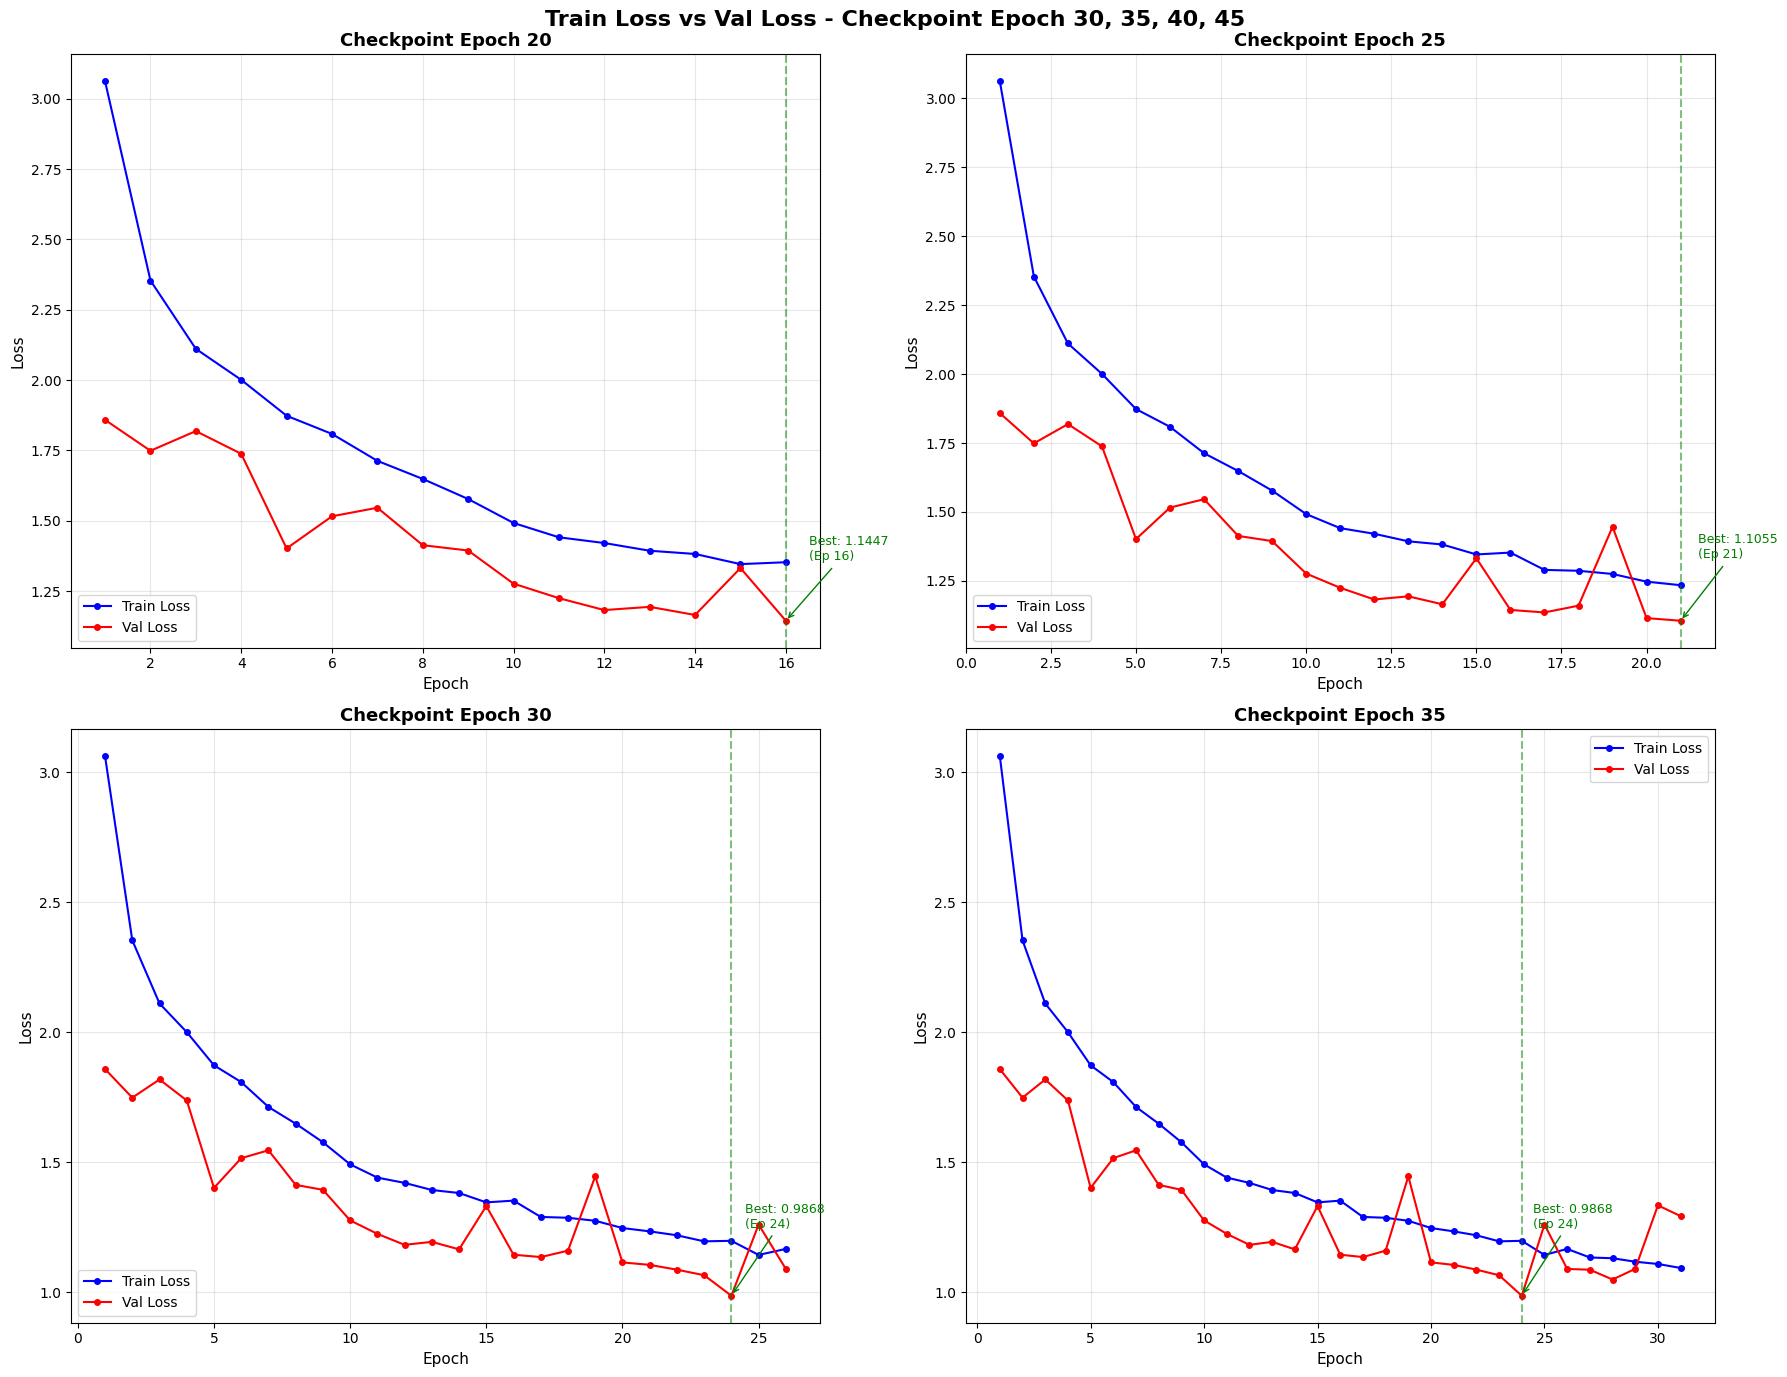


Biểu đồ đã lưu tại: /content/drive/MyDrive/U2Net_saved_models/u2net/saved_models/loss_chart_checkpoints.png


In [ ]:
import torch
import matplotlib.pyplot as plt
import os

# Đường dẫn model trên Google Drive (Colab)
MODEL_DIR = '/content/drive/MyDrive/U2Net_saved_models/u2net/saved_models'

# Danh sách checkpoint cần vẽ
checkpoint_epochs = [20, 25, 30, 35]
checkpoint_files = {ep: os.path.join(MODEL_DIR, f'u2net_epoch_{ep}.pth') for ep in checkpoint_epochs}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (ep, path) in enumerate(checkpoint_files.items()):
    ax = axes[idx]

    if not os.path.exists(path):
        ax.set_title(f'Epoch {ep} - Không tìm thấy file', fontsize=13, color='red')
        ax.text(0.5, 0.5, f'File không tồn tại:\n{path}', ha='center', va='center', fontsize=10, transform=ax.transAxes)
        print(f'Không tìm thấy: {path}')
        continue

    ckpt = torch.load(path, map_location='cpu')
    train_losses = ckpt.get('train_losses_per_epoch', [])
    val_losses = ckpt.get('val_losses_per_epoch', [])

    if not train_losses and not val_losses:
        ax.set_title(f'Epoch {ep} - Không có dữ liệu loss', fontsize=13, color='red')
        print(f'Checkpoint epoch {ep} không chứa dữ liệu loss theo epoch.')
        continue

    # Vẽ Train Loss và Val Loss trên cùng 1 biểu đồ
    if train_losses:
        ax.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', markersize=4, label='Train Loss')
    if val_losses:
        ax.plot(range(1, len(val_losses) + 1), val_losses, 'r-o', markersize=4, label='Val Loss')

    # Đánh dấu best val loss
    if val_losses:
        best_val_ep = val_losses.index(min(val_losses)) + 1
        best_val = min(val_losses)
        ax.axvline(x=best_val_ep, color='green', linestyle='--', alpha=0.5)
        ax.annotate(f'Best: {best_val:.4f}\n(Ep {best_val_ep})',
                    xy=(best_val_ep, best_val),
                    xytext=(best_val_ep + 0.5, best_val + (max(val_losses) - min(val_losses)) * 0.3),
                    arrowprops=dict(arrowstyle='->', color='green'),
                    fontsize=9, color='green')

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(f'Checkpoint Epoch {ep}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # In thông tin
    print(f'--- Checkpoint Epoch {ep} ---')
    if train_losses:
        print(f'  Train Loss cuối (epoch {len(train_losses)}): {train_losses[-1]:.4f}')
    if val_losses:
        print(f'  Val Loss cuối  (epoch {len(val_losses)}): {val_losses[-1]:.4f}')
        print(f'  Val Loss thấp nhất: {min(val_losses):.4f} (Epoch {best_val_ep})')

plt.suptitle('Train Loss vs Val Loss - Checkpoint Epoch 30, 35, 40, 45', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'loss_chart_checkpoints.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBiểu đồ đã lưu tại: {os.path.join(MODEL_DIR, "loss_chart_checkpoints.png")}')

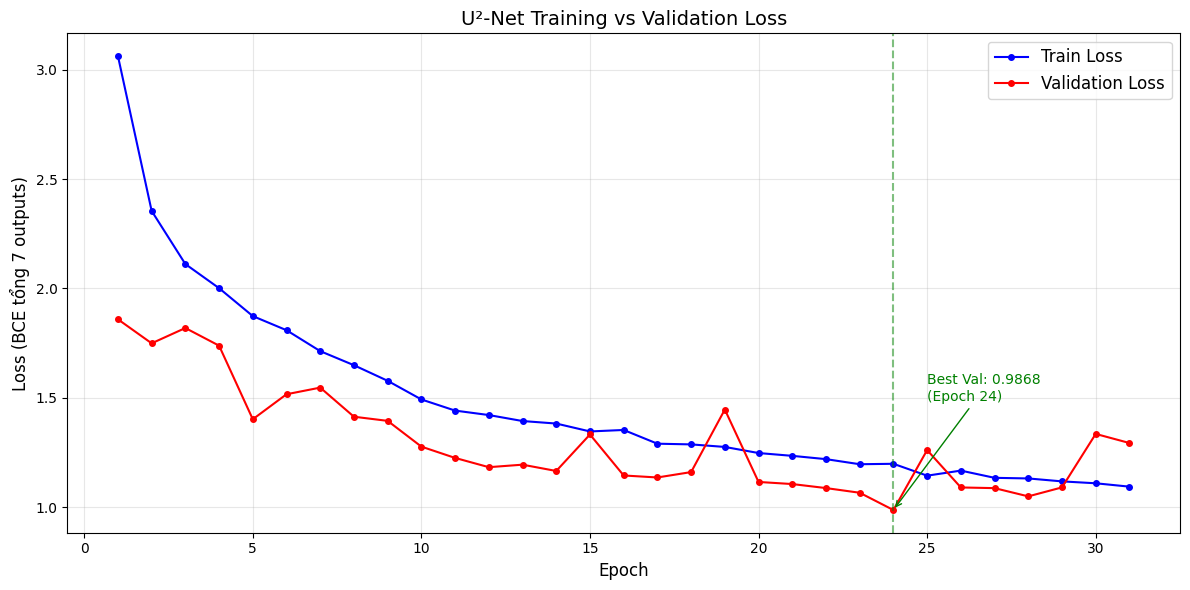


Biểu đồ đã lưu tại: /content/drive/MyDrive/U2Net_saved_models/u2net/saved_models/loss_chart.png
Train Loss cuối:      1.0936
Val Loss cuối:        1.2932
Val Loss thấp nhất:   0.9868 (Epoch 24)


In [ ]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ Train Loss vs Validation Loss
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

epochs_range = range(1, len(train_losses_per_epoch) + 1)

ax.plot(epochs_range, train_losses_per_epoch, 'b-o', label='Train Loss', markersize=4)
ax.plot(epochs_range, val_losses_per_epoch, 'r-o', label='Validation Loss', markersize=4)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (BCE tổng 7 outputs)', fontsize=12)
ax.set_title('U²-Net Training vs Validation Loss', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Đánh dấu epoch có val loss thấp nhất
if val_losses_per_epoch:
    best_epoch = val_losses_per_epoch.index(min(val_losses_per_epoch)) + 1
    best_val = min(val_losses_per_epoch)
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)
    ax.annotate(f'Best Val: {best_val:.4f}\n(Epoch {best_epoch})',
                xy=(best_epoch, best_val),
                xytext=(best_epoch + 1, best_val + 0.5),
                arrowprops=dict(arrowstyle='->', color='green'),
                fontsize=10, color='green')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'loss_chart.png'), dpi=150)
plt.show()

print(f'\nBiểu đồ đã lưu tại: {os.path.join(MODEL_DIR, "loss_chart.png")}')
print(f'Train Loss cuối:      {train_losses_per_epoch[-1]:.4f}' if train_losses_per_epoch else '')
print(f'Val Loss cuối:        {val_losses_per_epoch[-1]:.4f}' if val_losses_per_epoch else '')
if val_losses_per_epoch:
    print(f'Val Loss thấp nhất:   {min(val_losses_per_epoch):.4f} (Epoch {val_losses_per_epoch.index(min(val_losses_per_epoch))+1})')

## Bước 7: Lưu model cuối cùng

In [ ]:
final_save_path = os.path.join(MODEL_DIR, f'{MODEL_NAME}_final.pth')
torch.save(net.state_dict(), final_save_path)
print(f'Đã lưu model cuối cùng: {final_save_path}')

# Copy lên Drive nếu có
if DRIVE_SAVE_DIR:
    try:
        import shutil
        shutil.copy2(final_save_path, os.path.join(DRIVE_SAVE_DIR, f'{MODEL_NAME}_final.pth'))
        print(f'Đã copy lên Google Drive: {DRIVE_SAVE_DIR}')
    except Exception as e:
        print(f'Lỗi copy lên Drive: {e}')

Đã lưu model cuối cùng: /content/drive/MyDrive/U2Net_saved_models/u2net/saved_models/u2net_final.pth
Lỗi copy lên Drive: '/content/drive/MyDrive/U2Net_saved_models/u2net/saved_models/u2net_final.pth' and '/content/drive/MyDrive/U2Net_saved_models/u2net/saved_models/u2net_final.pth' are the same file


## Bước 8: Đánh giá model theo metrics trong bài báo U²-Net

Bài báo **Qin et al. (Pattern Recognition 2020)** đánh giá model bằng các metrics chuẩn cho Salient Object Detection:

| Metric | Ký hiệu | Tốt khi | Mô tả |
|--------|---------|---------|-------|
| Mean Absolute Error | MAE (↓) | Gần 0 | Sai số pixel-wise trung bình giữa predicted map và GT |
| Max F-measure | maxFβ (↑) | Gần 1 | Max F-score qua 255 ngưỡng, β²=0.3 |
| Mean F-measure | meanFβ (↑) | Gần 1 | Trung bình F-score qua 255 ngưỡng |
| S-measure | Sm (↑) | Gần 1 | Đánh giá structural similarity (Fan et al. ICCV 2017) |
| E-measure | Em (↑) | Gần 1 | Enhanced alignment measure (Fan et al. IJCAI 2018) |
| Weighted F-measure | Fβw (↑) | Gần 1 | F-measure có trọng số theo độ quan trọng pixel |

> Cell bên dưới chạy evaluation trên **tập validation (20%)** sử dụng model best đã lưu.  
> Để đánh giá đúng chuẩn paper, nên chạy trên tập test riêng (DUTS-TE).

### Ghi chú khi chạy cell đánh giá

- Cell này sẽ chạy suy luận trên toàn bộ tập validation nên có thể mất khá nhiều thời gian.
- Hãy chắc chắn bạn đã chạy xong các cell tạo `val_img_list`, `val_lbl_list`, `MODEL_DIR`, và load model.
- Nếu thiếu model `u2net_final.pth`, cell sẽ fallback sang model đang có trong RAM (`net`).
- Kết quả metrics và biểu đồ sẽ được lưu tại thư mục `saved_models/u2net/`.
- Để so sánh công bằng với paper, nên đánh giá trên DUTS-TE thay vì tập validation tách từ DUTS-TR.

Đã load model từ: /content/drive/MyDrive/U2Net_saved_models/u2net/saved_models/u2net_best.pth
Dùng tập validation đã chia (2111 ảnh)

Bắt đầu inference và tính metrics...
  [100/2111] MAE=0.0646 | maxF=0.9600 | Sm=0.9363
  [200/2111] MAE=0.0702 | maxF=0.9508 | Sm=0.9318
  [300/2111] MAE=0.0706 | maxF=0.9441 | Sm=0.9284
  [400/2111] MAE=0.0700 | maxF=0.9435 | Sm=0.9279
  [500/2111] MAE=0.0705 | maxF=0.9410 | Sm=0.9243
  [600/2111] MAE=0.0720 | maxF=0.9415 | Sm=0.9224
  [700/2111] MAE=0.0728 | maxF=0.9411 | Sm=0.9222
  [800/2111] MAE=0.0726 | maxF=0.9411 | Sm=0.9232
  [900/2111] MAE=0.0725 | maxF=0.9410 | Sm=0.9239
  [1000/2111] MAE=0.0729 | maxF=0.9407 | Sm=0.9236
  [1100/2111] MAE=0.0715 | maxF=0.9427 | Sm=0.9252
  [1200/2111] MAE=0.0715 | maxF=0.9440 | Sm=0.9261
  [1300/2111] MAE=0.0722 | maxF=0.9424 | Sm=0.9251
  [1400/2111] MAE=0.0721 | maxF=0.9425 | Sm=0.9254
  [1500/2111] MAE=0.0718 | maxF=0.9427 | Sm=0.9255
  [1600/2111] MAE=0.0715 | maxF=0.9432 | Sm=0.9260
  [1700/2111] MAE=0.07

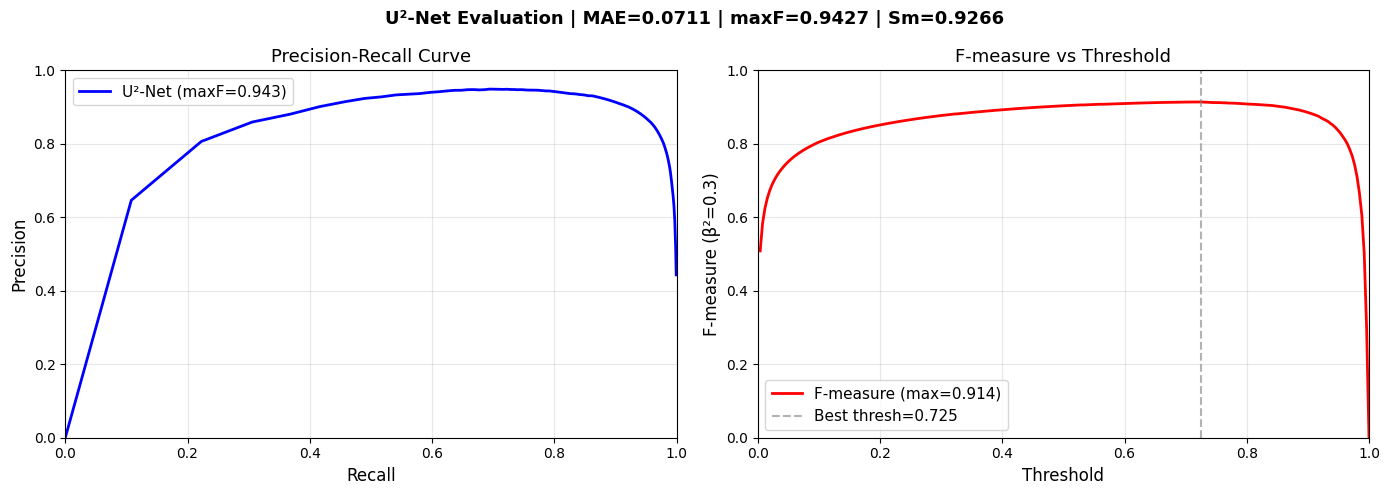


Biểu đồ đã lưu tại: /content/drive/MyDrive/U2Net_saved_models/u2net/saved_models/eval_metrics_chart.png


In [ ]:
#=======================================================
# ĐÁNH GIÁ MODEL THEO METRICS TRONG BÀI BÁO U²-Net
# Qin et al., Pattern Recognition 2020
# Metrics: MAE, maxFβ, meanFβ, S-measure, E-measure, Weighted-F
#=======================================================
import torch
import torch.nn as nn
import numpy as np
import os
import glob
import sys
from PIL import Image
import torchvision.transforms as transforms
from torch.autograd import Variable
import matplotlib.pyplot as plt
import matplotlib
from scipy.ndimage import convolve

# ---- 0. Load model ----
# Đường dẫn model final trên Google Drive (Colab)
EVAL_CKPT = '/content/drive/MyDrive/U2Net_saved_models/u2net/saved_models/u2net_final.pth'

sys.path.insert(0, PROJECT_DIR)
from model import U2NET, U2NETP
from data_loader import RescaleT, ToTensorLab, SalObjDataset

eval_model_name = 'u2net'  # hoặc 'u2netp'
eval_net = U2NET(3, 1) if eval_model_name == 'u2net' else U2NETP(3, 1)

if os.path.exists(EVAL_CKPT):
    ckpt = torch.load(EVAL_CKPT, map_location='cpu')
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        eval_net.load_state_dict(ckpt['model_state_dict'])
    else:
        eval_net.load_state_dict(ckpt)
    print(f'Đã load model từ: {EVAL_CKPT}')
else:
    print(f'CẢNH BÁO: Không tìm thấy {EVAL_CKPT}')
    print('Dùng model đang có trong memory (net) để đánh giá...')
    eval_net = net  # fallback dùng model đang train

device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_net = eval_net.to(device)
eval_net.eval()

#=======================================================
# ---- 1. Định nghĩa các hàm tính metrics ----
#=======================================================

def compute_mae(pred, gt):
    """Mean Absolute Error - metric chính trong bài báo U²-Net"""
    return float(np.mean(np.abs(pred.astype(np.float64) - gt.astype(np.float64))))


def compute_f_measure_curve(pred, gt, beta2=0.3, num_thresh=255):
    """
    Tính F-measure curve qua 255 ngưỡng (0~255).
    Trả về: precisions, recalls, f_measures, max_f, mean_f
    β² = 0.3 theo Achanta et al. (chuẩn bài báo U²-Net)
    """
    pred_uint8 = (pred * 255).astype(np.uint8)
    gt_binary  = (gt >= 0.5).astype(np.float64)
    gt_sum = gt_binary.sum()

    precisions, recalls, f_measures = [], [], []
    for thresh in range(1, num_thresh + 1):
        pred_bin = (pred_uint8 >= thresh).astype(np.float64)
        tp = (pred_bin * gt_binary).sum()
        prec = tp / (pred_bin.sum() + 1e-8)
        rec  = tp / (gt_sum + 1e-8)
        f = (1 + beta2) * prec * rec / (beta2 * prec + rec + 1e-8)
        precisions.append(prec)
        recalls.append(rec)
        f_measures.append(f)

    precisions  = np.array(precisions)
    recalls     = np.array(recalls)
    f_measures  = np.array(f_measures)
    return precisions, recalls, f_measures, f_measures.max(), f_measures.mean()


def compute_s_measure(pred, gt, alpha=0.5):
    """
    S-measure (Structure Measure) - Fan et al. ICCV 2017
    S = alpha * S_o + (1 - alpha) * S_r
    """
    def _object_score(pred, gt):
        """Object-aware structural similarity"""
        gt = gt.astype(np.float64)
        pred = pred.astype(np.float64)
        fg = pred * gt
        bg = (1 - pred) * (1 - gt)
        u = gt.mean()
        if u == 0:
            return 1 - pred.mean()
        if u == 1:
            return pred.mean()
        # Foreground similarity
        x = fg[gt > 0]
        o_fg = 2 * x.mean() / (x.mean()**2 + 1.0 + 1e-8) if len(x) > 0 else 0.0
        # Background similarity
        y = bg[gt == 0]
        o_bg = 2 * y.mean() / (y.mean()**2 + 1.0 + 1e-8) if len(y) > 0 else 0.0
        return u * o_fg + (1 - u) * o_bg

    def _region_score(pred, gt):
        """Region-aware structural similarity"""
        H, W = gt.shape
        gt = gt.astype(np.float64)
        pred = pred.astype(np.float64)
        # Centroid of GT
        ys, xs = np.where(gt > 0.5)
        if len(xs) == 0:
            return 1.0 - pred.mean()
        cx = int(xs.mean())
        cy = int(ys.mean())
        # Split into 4 quadrants
        def _ssim_quad(p, g):
            if p.size == 0 or g.size == 0:
                return 0.0, 0
            pm, gm = p.mean(), g.mean()
            pv = p.var() + 1e-8
            gv = g.var() + 1e-8
            cov = ((p - pm) * (g - gm)).mean()
            ssim = (2 * pm * gm + 1e-8) * (2 * cov + 1e-8) / \
                   ((pm**2 + gm**2 + 1e-8) * (pv + gv + 1e-8))
            return ssim, p.size
        q1_s, n1 = _ssim_quad(pred[:cy, :cx],   gt[:cy, :cx])
        q2_s, n2 = _ssim_quad(pred[:cy, cx:],   gt[:cy, cx:])
        q3_s, n3 = _ssim_quad(pred[cy:, :cx],   gt[cy:, :cx])
        q4_s, n4 = _ssim_quad(pred[cy:, cx:],   gt[cy:, cx:])
        total = n1 + n2 + n3 + n4
        if total == 0:
            return 0.0
        return (n1*q1_s + n2*q2_s + n3*q3_s + n4*q4_s) / total

    pred_f = pred.astype(np.float64)
    gt_f   = gt.astype(np.float64)
    so = _object_score(pred_f, gt_f)
    sr = _region_score(pred_f, gt_f)
    return alpha * so + (1 - alpha) * sr


def compute_e_measure(pred, gt):
    """
    Enhanced Alignment Measure (E-measure) - Fan et al. IJCAI 2018
    Dùng ngưỡng adaptive (mean*2)
    """
    pred_f = pred.astype(np.float64)
    gt_f   = gt.astype(np.float64)
    # Adaptive threshold
    thresh = min(pred_f.mean() * 2, 1.0)
    pred_bin = (pred_f >= thresh).astype(np.float64)
    # Align matrix
    mu_p = pred_bin.mean()
    mu_g = gt_f.mean()
    align_p = pred_bin - mu_p
    align_g = gt_f   - mu_g
    align_mat = 2.0 * align_p * align_g / (align_p**2 + align_g**2 + 1e-8)
    enhanced = ((align_mat + 1)**2) / 4.0
    H, W = gt_f.shape
    return float(enhanced.sum() / (H * W - 1 + 1e-8))


def compute_weighted_f(pred, gt, beta2=1.0):
    """
    Weighted F-measure (Fβw) - Margolin et al.
    Gán trọng số theo khoảng cách đến biên GT để phạt nặng sai lầm ở vùng edge
    """
    pred_f = pred.astype(np.float64)
    gt_f   = (gt >= 0.5).astype(np.float64)
    # Tính weight map từ distance transform
    from scipy.ndimage import distance_transform_edt
    dst = distance_transform_edt(1 - gt_f)
    dst_norm = dst / (dst.max() + 1e-8)
    weight = 1.0 - dst_norm   # trọng số cao ở biên (edge)
    # Weighted TP, FP, FN
    tp_w  = (weight * pred_f * gt_f).sum()
    fp_w  = (weight * pred_f * (1 - gt_f)).sum()
    fn_w  = (weight * (1 - pred_f) * gt_f).sum()
    prec  = tp_w / (tp_w + fp_w + 1e-8)
    rec   = tp_w / (tp_w + fn_w + 1e-8)
    f_w   = (1 + beta2) * prec * rec / (beta2 * prec + rec + 1e-8)
    return float(f_w)


#=======================================================
# ---- 2. Inference và tính metrics trên tập Validation ----
#=======================================================

# DataLoader val (dùng lại val_img_list, val_lbl_list từ Bước 5)
# Nếu chưa có, tự lấy 20% dataset
try:
    _ = val_img_list
    print(f'Dùng tập validation đã chia ({len(val_img_list)} ảnh)')
except NameError:
    import glob
    from sklearn.model_selection import train_test_split
    all_imgs = glob.glob(os.path.join(DATA_DIR, TRA_IMAGE_DIR, '*.jpg'))
    all_lbls = [os.path.join(DATA_DIR, TRA_LABEL_DIR,
                             os.path.splitext(os.path.basename(p))[0] + '.png')
                for p in all_imgs]
    _, val_img_list, _, val_lbl_list = train_test_split(
        all_imgs, all_lbls, test_size=0.2, random_state=42)
    print(f'Tạo lại tập validation ({len(val_img_list)} ảnh)')

print('\nBắt đầu inference và tính metrics...')

all_mae, all_maxF, all_meanF, all_sm, all_em, all_wf = [], [], [], [], [], []
all_precisions = np.zeros(255)
all_recalls    = np.zeros(255)

transform_eval = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

with torch.no_grad():
    for idx, (img_path, lbl_path) in enumerate(zip(val_img_list, val_lbl_list)):
        # Load ảnh
        img = Image.open(img_path).convert('RGB')
        inp = transform_eval(img).unsqueeze(0).to(device)

        # Load GT mask
        if not os.path.exists(lbl_path):
            continue
        gt_pil = Image.open(lbl_path).convert('L')

        # Inference
        d0, *_ = eval_net(inp)
        pred_tensor = d0.squeeze().cpu()
        # Resize pred về kích thước GT gốc
        pred_pil = transforms.ToPILImage()(pred_tensor).resize(gt_pil.size, Image.BILINEAR)

        pred_np = np.array(pred_pil).astype(np.float64) / 255.0
        gt_np   = np.array(gt_pil).astype(np.float64)   / 255.0

        # Tính từng metric
        mae = compute_mae(pred_np, gt_np)
        precs, recs, fms, max_f, mean_f = compute_f_measure_curve(pred_np, gt_np)
        sm  = compute_s_measure(pred_np, gt_np)
        em  = compute_e_measure(pred_np, gt_np)
        wf  = compute_weighted_f(pred_np, gt_np)

        all_mae.append(mae)
        all_maxF.append(max_f)
        all_meanF.append(mean_f)
        all_sm.append(sm)
        all_em.append(em)
        all_wf.append(wf)
        all_precisions += precs
        all_recalls    += recs

        if (idx + 1) % 100 == 0:
            print(f'  [{idx+1}/{len(val_img_list)}] MAE={np.mean(all_mae):.4f} | '
                  f'maxF={np.mean(all_maxF):.4f} | Sm={np.mean(all_sm):.4f}')

n = len(all_mae)
avg_mae   = np.mean(all_mae)
avg_maxF  = np.mean(all_maxF)
avg_meanF = np.mean(all_meanF)
avg_sm    = np.mean(all_sm)
avg_em    = np.mean(all_em)
avg_wf    = np.mean(all_wf)
avg_precs = all_precisions / n
avg_recs  = all_recalls    / n

print('\n' + '='*60)
print(f'  KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ({n} ảnh)')
print('='*60)
print(f'  MAE        (↓): {avg_mae:.4f}  (paper U2Net DUTS-TE: 0.044)')
print(f'  maxFβ      (↑): {avg_maxF:.4f}  (paper U2Net DUTS-TE: 0.873)')
print(f'  meanFβ     (↑): {avg_meanF:.4f}')
print(f'  S-measure  (↑): {avg_sm:.4f}')
print(f'  E-measure  (↑): {avg_em:.4f}')
print(f'  Weighted-F (↑): {avg_wf:.4f}')
print('='*60)
print('  Lưu ý: Đánh giá trên val 20% của DUTS-TR, không phải DUTS-TE.')
print('  Để so sánh đúng với paper, chạy trên tập DUTS-TE riêng biệt.')

#=======================================================
# ---- 3. Vẽ PR Curve ----
#=======================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve
axes[0].plot(avg_recs, avg_precs, 'b-', linewidth=2, label=f'U²-Net (maxF={avg_maxF:.3f})')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curve', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3)

# F-measure vs Threshold curve
thresholds = np.linspace(1/255, 1.0, 255)
# Tính F qua các ngưỡng từ avg P/R
beta2 = 0.3
fms_curve = (1 + beta2) * avg_precs * avg_recs / (beta2 * avg_precs + avg_recs + 1e-8)
axes[1].plot(thresholds, fms_curve, 'r-', linewidth=2,
             label=f'F-measure (max={fms_curve.max():.3f})')
axes[1].axvline(x=thresholds[fms_curve.argmax()], color='gray',
                linestyle='--', alpha=0.6, label=f'Best thresh={thresholds[fms_curve.argmax()]:.3f}')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('F-measure (β²=0.3)', fontsize=12)
axes[1].set_title('F-measure vs Threshold', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'U²-Net Evaluation | MAE={avg_mae:.4f} | maxF={avg_maxF:.4f} | Sm={avg_sm:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()

chart_path = os.path.join(MODEL_DIR, 'eval_metrics_chart.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nBiểu đồ đã lưu tại: {chart_path}')

## Biểu đồ Metrics theo Epoch

Chạy sau khi training hoàn tất để xem MAE, maxFβ và S-measure thay đổi qua từng epoch.

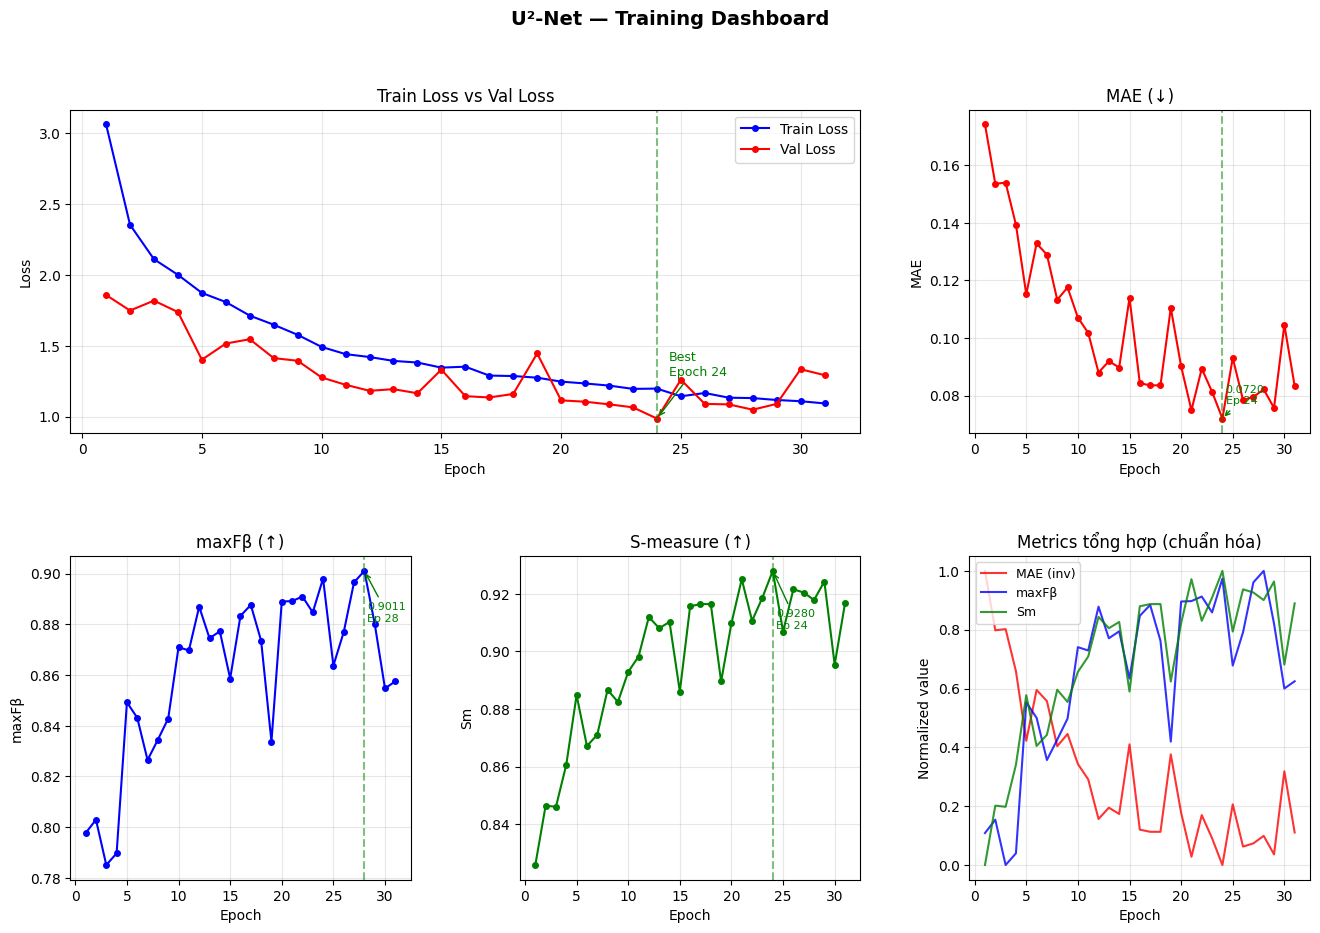


Biểu đồ đã lưu: /content/drive/MyDrive/U2Net_saved_models/u2net/saved_models/metrics_per_epoch.png

Tóm tắt kết quả tốt nhất:
  MAE  thấp nhất : 0.0720  (Epoch 24)
  maxFβ cao nhất : 0.9011  (Epoch 28)
  Sm   cao nhất  : 0.9280  (Epoch 24)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Đường dẫn lưu biểu đồ trên Google Drive (Colab)
MODEL_DIR = '/content/drive/MyDrive/U2Net_saved_models/u2net/saved_models'

epochs_r = range(1, len(train_losses_per_epoch) + 1)
has_metrics = len(mae_per_epoch) == len(train_losses_per_epoch)

if has_metrics:
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

    # 1. Train vs Val Loss
    ax0 = fig.add_subplot(gs[0, :2])
    ax0.plot(epochs_r, train_losses_per_epoch, 'b-o', markersize=4, label='Train Loss')
    ax0.plot(epochs_r, val_losses_per_epoch,   'r-o', markersize=4, label='Val Loss')
    if val_losses_per_epoch:
        _be = val_losses_per_epoch.index(min(val_losses_per_epoch)) + 1
        ax0.axvline(_be, color='green', linestyle='--', alpha=0.5)
        ax0.annotate(f'Best\nEpoch {_be}', xy=(_be, min(val_losses_per_epoch)),
                     xytext=(_be+0.5, min(val_losses_per_epoch)+0.3),
                     fontsize=9, color='green',
                     arrowprops=dict(arrowstyle='->', color='green'))
    ax0.set_title('Train Loss vs Val Loss', fontsize=12)
    ax0.set_xlabel('Epoch'); ax0.set_ylabel('Loss')
    ax0.legend(); ax0.grid(True, alpha=0.3)

    # 2. MAE per epoch
    ax1 = fig.add_subplot(gs[0, 2])
    ax1.plot(epochs_r, mae_per_epoch, 'r-o', markersize=4)
    ax1.set_title('MAE (↓)', fontsize=12)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('MAE')
    ax1.grid(True, alpha=0.3)
    _best_mae_ep = mae_per_epoch.index(min(mae_per_epoch)) + 1
    ax1.axvline(_best_mae_ep, color='green', linestyle='--', alpha=0.5)
    ax1.annotate(f'{min(mae_per_epoch):.4f}\nEp {_best_mae_ep}',
                 xy=(_best_mae_ep, min(mae_per_epoch)),
                 xytext=(_best_mae_ep+0.3, min(mae_per_epoch)+0.005),
                 fontsize=8, color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))

    # 3. maxFβ per epoch
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(epochs_r, maxF_per_epoch, 'b-o', markersize=4)
    ax2.set_title('maxFβ (↑)', fontsize=12)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('maxFβ')
    ax2.grid(True, alpha=0.3)
    _best_f_ep = maxF_per_epoch.index(max(maxF_per_epoch)) + 1
    ax2.axvline(_best_f_ep, color='green', linestyle='--', alpha=0.5)
    ax2.annotate(f'{max(maxF_per_epoch):.4f}\nEp {_best_f_ep}',
                 xy=(_best_f_ep, max(maxF_per_epoch)),
                 xytext=(_best_f_ep+0.3, max(maxF_per_epoch)-0.02),
                 fontsize=8, color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))

    # 4. S-measure per epoch
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(epochs_r, sm_per_epoch, 'g-o', markersize=4)
    ax3.set_title('S-measure (↑)', fontsize=12)
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('Sm')
    ax3.grid(True, alpha=0.3)
    _best_sm_ep = sm_per_epoch.index(max(sm_per_epoch)) + 1
    ax3.axvline(_best_sm_ep, color='green', linestyle='--', alpha=0.5)
    ax3.annotate(f'{max(sm_per_epoch):.4f}\nEp {_best_sm_ep}',
                 xy=(_best_sm_ep, max(sm_per_epoch)),
                 xytext=(_best_sm_ep+0.3, max(sm_per_epoch)-0.02),
                 fontsize=8, color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))

    # 5. All metrics normalized (0-1) trên cùng 1 trục
    ax4 = fig.add_subplot(gs[1, 2])
    import numpy as np
    def _norm(lst):
        a = np.array(lst); mn, mx = a.min(), a.max()
        return (a - mn) / (mx - mn + 1e-8)
    ax4.plot(epochs_r, _norm(mae_per_epoch),  'r-', label='MAE (inv)', alpha=0.8)
    ax4.plot(epochs_r, _norm(maxF_per_epoch), 'b-', label='maxFβ',     alpha=0.8)
    ax4.plot(epochs_r, _norm(sm_per_epoch),   'g-', label='Sm',        alpha=0.8)
    ax4.set_title('Metrics tổng hợp (chuẩn hóa)', fontsize=12)
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('Normalized value')
    ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)

    plt.suptitle('U²-Net — Training Dashboard', fontsize=14, fontweight='bold')
    chart_path = os.path.join(MODEL_DIR, 'metrics_per_epoch.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nBiểu đồ đã lưu: {chart_path}')
    print(f'\nTóm tắt kết quả tốt nhất:')
    print(f'  MAE  thấp nhất : {min(mae_per_epoch):.4f}  (Epoch {mae_per_epoch.index(min(mae_per_epoch))+1})')
    print(f'  maxFβ cao nhất : {max(maxF_per_epoch):.4f}  (Epoch {maxF_per_epoch.index(max(maxF_per_epoch))+1})')
    print(f'  Sm   cao nhất  : {max(sm_per_epoch):.4f}  (Epoch {sm_per_epoch.index(max(sm_per_epoch))+1})')
else:
    print('Chưa có dữ liệu metrics per epoch. Hãy chạy lại training với code mới.')
    # Vẽ loss chart đơn giản nếu chưa có metrics
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs_r, train_losses_per_epoch, 'b-o', markersize=4, label='Train Loss')
    ax.plot(epochs_r, val_losses_per_epoch,   'r-o', markersize=4, label='Val Loss')
    ax.set_title('Train Loss vs Val Loss'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.show()

## (Tùy chọn) Chạy inference để kiểm tra model

In [ ]:
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

def predict(image_path, model, device):
    img = Image.open(image_path).convert('RGB')
    orig_size = img.size
    transform = transforms.Compose([
        transforms.Resize((320, 320)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    inp = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        d0, *_ = model(inp)
    pred = d0.squeeze().cpu().numpy()
    pred = (pred - pred.min()) / (pred.max() - pred.min() + 1e-8)
    mask = Image.fromarray((pred * 255).astype(np.uint8)).resize(orig_size)
    return img, mask

# Chỉnh đường dẫn ảnh test
TEST_IMAGE = os.path.join(PROJECT_DIR, 'test_data', 'test_images', '0003.jpg')  # <-- Chỉnh lại

if os.path.exists(TEST_IMAGE):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    img, mask = predict(TEST_IMAGE, net, device)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img); axes[0].set_title('Ảnh gốc'); axes[0].axis('off')
    axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Salient Map'); axes[1].axis('off')
    plt.tight_layout()

    # Lưu hình prediction vào Google Drive
    fig_save_path = os.path.join('/content/drive/MyDrive/U2Net_saved_models/u2net/saved_models', 'inference_example.png')
    plt.savefig(fig_save_path, dpi=150, bbox_inches='tight')
    print(f'Biểu đồ đã lưu: {fig_save_path}')
    plt.show()
else:
    print(f'Không tìm thấy ảnh test: {TEST_IMAGE}')
    print('Hãy chỉnh lại đường dẫn TEST_IMAGE.')